In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
# %matplotlib notebook

# https://stackoverflow.com/questions/28320247/density-plot-on-a-sphere-python

In [4]:
import numpy as np
import matplotlib.pyplot as plt
plt.set_loglevel('critical')
SMALL_SIZE = 10
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

import pandas as pd
import os
import pickle
import sys
import plotly.graph_objects as go
import datetime

from dipy.core.sphere import disperse_charges, Sphere, HemiSphere

from fury import actor, window
from IPython.core.display import Image
from PIL import Image as PILImage

sys.path.append('../st_validate/')
import sta_validate
# import histology
import apsym_kmeans

In [5]:
path = "/home/brysongray/bmap/fibermetric/st_validation"
error_key = "error"
DATE = datetime.datetime.today().strftime("%m-%d-%y")

# make figures for 2D experiments

## Experiment 1: 2D single orienation

In [9]:
row = pickle.load(open(os.path.join(path,sta_out,files[1]), 'rb'))

In [10]:
row

,derivative_sigma,tensor_sigma,AI,period,width,angles,error
0,0.15,0.000000,3.0,10.0,1.0,"[1.3169302537775396, 1.4279966607226333, 1.205...",36.272727
1,0.15,0.555556,3.0,10.0,1.0,"[1.3169302537775396, 1.4279966607226333, 1.205...",35.818182
2,0.15,1.111111,3.0,10.0,1.0,"[1.3169302537775396, 1.4279966607226333, 1.205...",31.909091
3,0.15,1.666667,3.0,10.0,1.0,"[1.3169302537775396, 1.4279966607226333, 1.205...",29.181818
4,0.15,2.222222,3.0,10.0,1.0,"[1.3169302537775396, 1.4279966607226333, 1.205...",21.121212
...,...,...,...,...,...,...,...
95,2.50,2.777778,3.0,10.0,1.0,"[1.3169302537775396, 1.4279966607226333, 1.205...",11.121212
96,2.50,3.333333,3.0,10.0,1.0,"[1.3169302537775396, 1.4279966607226333, 1.205...",9.787879
97,2.50,3.888889,3.0,10.0,1.0,"[1.3169302537775396, 1.4279966607226333, 1.205...",3.909091
98,2.50,4.444444,3.0,10.0,1.0,"[1.3169302537775396, 1.4279966607226333, 1.205...",7.060606


In [11]:
len(errors_df)

156300

In [6]:
# concatenate all the pandas dataframes corresponding to phantoms with a single angle
sta_out = 'sta_2d_3_angles_out'
# sta_out = 'sta_2d_out_7-25-24/'

# sta_out = '../outputs/sta_validate_outputs/sta_2d_BF_out/'
# sta_out = '../outputs/sta_validate_outputs/sta_2d_iso-blur_out/'
# sta_out = '../outputs/sta_validate_outputs/sta_2d_iso-blur_out_v7/'
# sta_out = '../outputs/sta_validate_outputs/sta_2d_out/'
# sta_out = '/home/brysongray/bmap/fibermetric/st_validation/sta_2d-96_out_v7/'

files = os.listdir(os.path.join(path, sta_out))
files = [f for f in files if f.split('theta-')[1][4]=='.'] # only get the files with one line angle
valid_files = []
for f in files:
    try:
        with open(os.path.join(path, sta_out, f), 'rb') as file:
            pickle.load(file)
        valid_files.append(f)
    except (EOFError, pickle.UnpicklingError):
        print(f"Skipping invalid or corrupted file: {f}")

if valid_files:
    errors_df = pickle.load(open(os.path.join(path, sta_out, valid_files[0]), 'rb'))
    for f in valid_files[1:]:
        errors_df = pd.concat([errors_df, pickle.load(open(os.path.join(path, sta_out, f), 'rb'))], axis=0)
else:
    raise ValueError("No valid files found to load data.")
derivative_sigmas = errors_df['derivative_sigma'].unique()
tensor_sigmas = errors_df['tensor_sigma'].unique()
AI = np.sort(errors_df['AI'].unique())

print(len(files))
print(derivative_sigmas)
print(tensor_sigmas)
print(errors_df.iloc[0])

ValueError: No valid files found to load data.

In [30]:
out = '/home/brysongray/structure_tensor_validation/outputs'
name = '2d_single_angle_phantom_sta_errors_' + DATE + '.csv'
# name = '2d_three_angle_phantom_sta_errors_' + DATE + '.csv'
errors_df.to_csv(os.path.join(out, name))

## Figure 1: heatmap of errors for sigma 1 vs sigma 2 at each anisotropy

In [ ]:
print(len(errors_df))
# errors_df = errors_df[errors_df['period']!=7]
# print(len(errors_df))
# average errors_df over all angles and periods
if error_key == 'error':
    errors_df_grouped = errors_df.groupby(['derivative_sigma', 'tensor_sigma', 'AI'])[error_key].median().reset_index()
else:
    errors_df_grouped = errors_df.groupby(['derivative_sigma', 'tensor_sigma', 'AI'])['mean_err'].median().reset_index()

errors = errors_df_grouped['error'].values.reshape((len(derivative_sigmas), len(tensor_sigmas), len(AI)))

239900


derivative_sigma     0.150000
tensor_sigma         0.555556
AI                   3.000000
error               21.878788
Name: 10, dtype: float64

In [17]:
errors_df_grouped[:10]

,derivative_sigma,tensor_sigma,AI,error
0,0.15,0.000000,1.000000,21.727273
1,0.15,0.000000,2.000000,24.590909
2,0.15,0.000000,3.000000,23.303030
3,0.15,0.000000,4.000000,23.484848
4,0.15,0.000000,5.052632,24.303030
5,0.15,0.000000,6.000000,24.712121
6,0.15,0.000000,6.857143,24.348485
7,0.15,0.000000,8.000000,25.166667
8,0.15,0.555556,1.000000,16.454545
9,0.15,0.555556,2.000000,22.909091


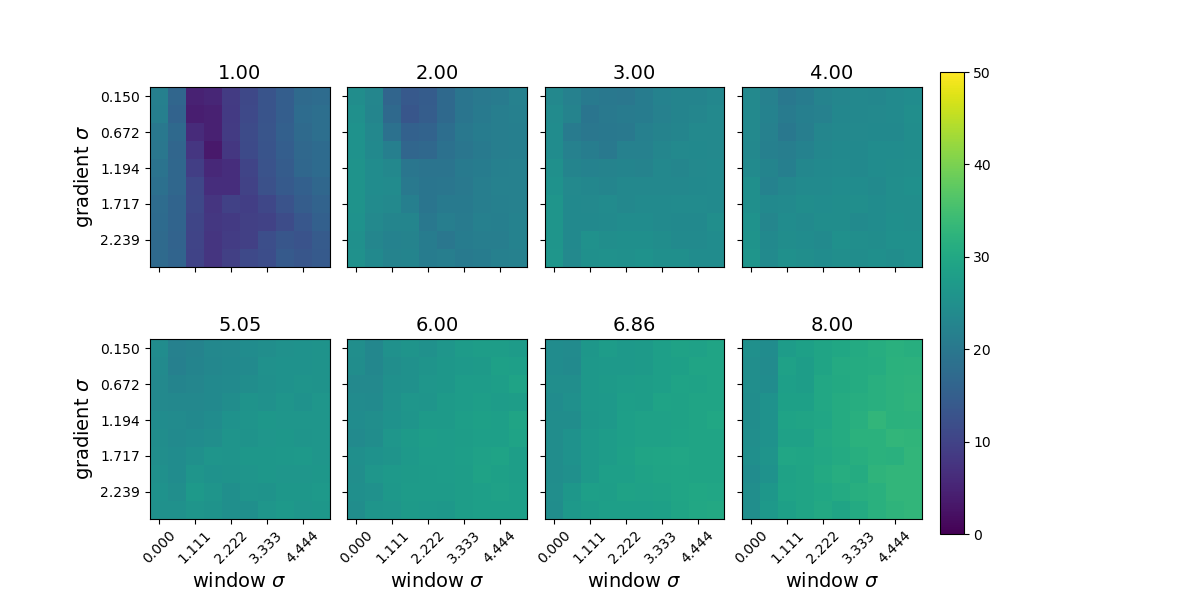

In [20]:
rows = 2
cols = 4
vm = 50
fig, axs = plt.subplots(rows,cols, figsize=(12,6), sharex=True, sharey=True)
for i in range(len(AI)):
    error = errors[...,i]
    axs[i//cols,i%cols].imshow(error, vmin=0, vmax=vm)
    axs[i//cols,i%cols].set_title(f'{AI[i]:.2f}')
    # set x tick labels
    # set the locations of the xticks and yticks
    xticklabels = [f'{t:.3f}' for t in tensor_sigmas]
    yticklabels = [f'{d:.3f}' for d in derivative_sigmas]
    axs[i//cols, i%cols].set_xticks(np.arange(len(tensor_sigmas))[::2])
    axs[i//cols, i%cols].set_yticks(np.arange(len(derivative_sigmas))[::2])
    axs[i//cols, i%cols].set_xticklabels(xticklabels[::2], rotation=45)
    axs[i//cols, i%cols].set_yticklabels(yticklabels[::2])
    if i%cols==0:
        axs[i//cols,i%cols].set_ylabel(r'gradient $\sigma$')
    if i > cols * (rows-1) - 1:
        axs[i//cols,i%cols].set_xlabel(r'window $\sigma$')
    plt.subplots_adjust(wspace=0.1, hspace=0.2)
# add colorbar to the rightmean
cbar = fig.colorbar(axs[0,0].images[0], ax=axs, location='right', pad=0.02)
# fig.suptitle('2D Three Angles')

fig.savefig('../outputs/sta_validate_outputs/figures/heatmaps_2d_three_angle_'+DATE+'.png')

## figure 2: The smallest average single-angle error, optimized over sigmas, versus anisotropy ratio.

In [21]:
# min the error array over the first two axes
errors_min = np.min(errors, axis=(0,1))
errors_max = np.max(errors, axis=(0,1))
# # plot the min error for each anisotropy ratio
# plt.figure()
# # set figure title
# plt.plot(AI, errors_min, marker='o')
# plt.ylim(-1,56)
# plt.yticks(np.arange(0,60,5))
# plt.xlabel('anisotropy ratio')
# plt.ylabel('min error (degrees)')


In [22]:
errors_min

array([ 3.45454545, 13.28787879, 19.46969697, 19.96969697, 21.8030303 ,
       23.15151515, 24.01515152, 24.15151515])

## figure 3: The best sigma 1 and sigma 2 vs anisotropy ratio.

In [23]:
# get the sigmas at argmin of the error over the anisotropy axis
best_idx = np.empty((len(AI), 2))
for i in range(len(AI)):
    best_idx[i] = np.array(np.unravel_index(np.argmin(errors[...,i]), errors.shape[:-1]))

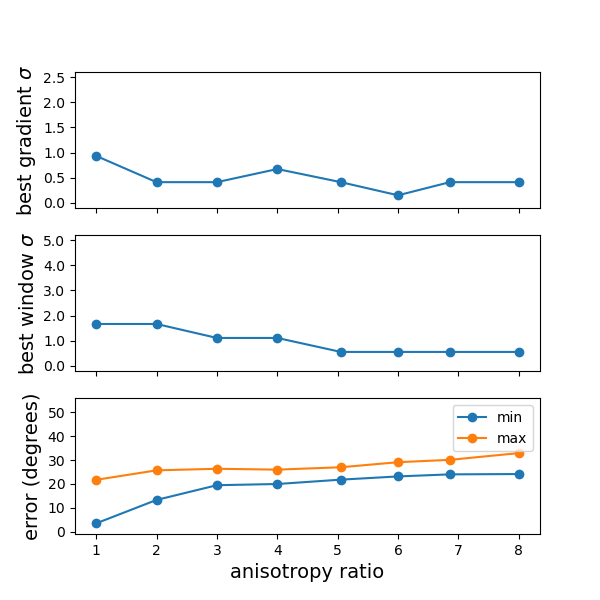

In [25]:
# plot the best sigma 1 and best sigma 2 versus the anisotropy ratio
fig, axs = plt.subplots(3, figsize=(6,6), sharex=True)
axs[0].plot(AI, derivative_sigmas[best_idx[:,0].astype(int)], marker='o')
axs[0].set_ylim(-0.1,2.6)
axs[0].set_yticks(np.arange(0.0,3.0,0.5))
axs[0].set_ylabel(r'best gradient $\sigma$')
axs[1].plot(AI, tensor_sigmas[best_idx[:,1].astype(int)], marker='o')
axs[1].set_ylim(-0.2,5.2)
yticklabels = [f'{y:.1f}'for y in np.arange(0.0,6.0,1.0)]
axs[1].set_yticks(np.arange(0.0,6.0,1.0))
axs[1].set_yticklabels(yticklabels)
axs[1].set_ylabel(r'best window $\sigma$')
axs[2].plot(AI, errors_min, marker='o')
axs[2].plot(AI, errors_max, marker='o')
axs[2].set_ylim(-1,56)
axs[2].set_yticks(np.arange(0,55,10))
axs[2].set_ylabel('error (degrees)')
axs[2].set_xlabel('anisotropy ratio')
axs[2].legend(['min', 'max'])
# fig.suptitle('2D Two Angles')

fig.savefig('../outputs/sta_validate_outputs/figures/2d_three_angle_lines_'+DATE+'.png')

## Experiment 2: 2D two angles

In [7]:
files = os.listdir(os.path.join(path,sta_out))
files = [f for f in files if f.split('theta-')[1][4]=='-'] # only get the files with two line angles
errors_df = pickle.load(open(os.path.join(path,sta_out,files[0]), 'rb'))
for f in files[1:]:
    errors_df = pd.concat([errors_df, pickle.load(open(os.path.join(path,sta_out,f), 'rb'))], axis=0)
derivative_sigmas = errors_df['derivative_sigma'].unique()
tensor_sigmas = errors_df['tensor_sigma'].unique()
AI = np.sort(errors_df['AI'].unique())
print(len(files))

2400


In [8]:
out = '/home/brysongray/structure_tensor_validation/outputs'
name = '2d_two_angle_phantom_sta_errors_' + DATE + '.csv'
errors_df.to_csv(os.path.join(out, name))

In [21]:
# average errors_df over all angles and periods
if error_key == 'error':
    errors_df_grouped = errors_df.groupby(['derivative_sigma', 'tensor_sigma', 'AI'])[error_key].median().reset_index()
else:
    errors_df_grouped = errors_df.groupby(['derivative_sigma', 'tensor_sigma', 'AI'])['mean_err'].median().reset_index()
errors_df_grouped.iloc[79:85]

errors = errors_df_grouped[error_key].values.reshape((len(derivative_sigmas), len(tensor_sigmas), len(AI)))

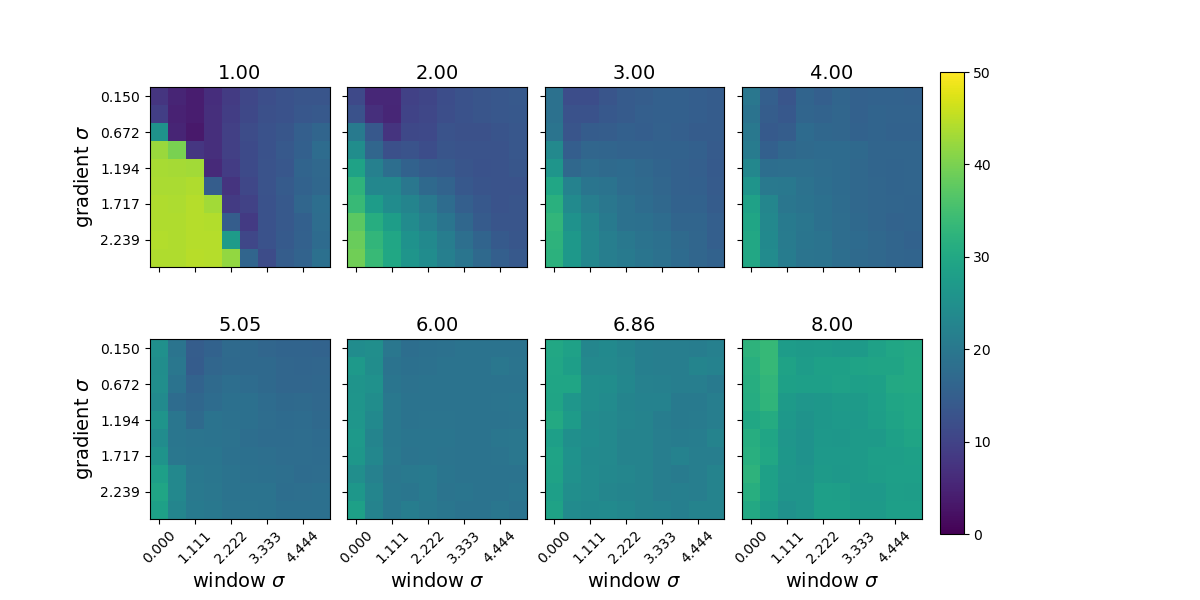

In [22]:
rows = 2
cols = 4
vm = 50
fig, axs = plt.subplots(rows,cols, figsize=(12,6), sharex=True, sharey=True)
for i in range(len(AI)):
    error = errors[...,i]
    axs[i//cols,i%cols].imshow(error, vmin=0, vmax=vm)
    axs[i//cols,i%cols].set_title(f'{AI[i]:.2f}')
    # set x tick labels
    # set the locations of the xticks and yticks
    xticklabels = [f'{t:.3f}' for t in tensor_sigmas]
    yticklabels = [f'{d:.3f}' for d in derivative_sigmas]
    axs[i//cols, i%cols].set_xticks(np.arange(len(tensor_sigmas))[::2])
    axs[i//cols, i%cols].set_yticks(np.arange(len(derivative_sigmas))[::2])
    axs[i//cols, i%cols].set_xticklabels(xticklabels[::2], rotation=45)
    axs[i//cols, i%cols].set_yticklabels(yticklabels[::2])
    if i%cols==0:
        axs[i//cols,i%cols].set_ylabel(r'gradient $\sigma$')
    if i > cols * (rows-1) - 1:
        axs[i//cols,i%cols].set_xlabel(r'window $\sigma$')
    plt.subplots_adjust(wspace=0.1, hspace=0.2)
# add colorbar to the right
cbar = fig.colorbar(axs[0,0].images[0], ax=axs, location='right', pad=0.02)

# fig.savefig('../outputs/sta_validate_outputs/figures/heatmaps_2d_two_angles_'+DATE+'.png')

In [117]:
# min the error array over the first two axes
errors_min = np.min(errors, axis=(0,1))
errors_max = np.max(errors, axis=(0,1))
# plot the min error for each anisotropy ratio
# plt.figure()
# # set figure title
# plt.plot(AI, errors_min, marker='o')
# plt.ylim(-1,56)
# plt.yticks(np.arange(0,60,5))
# plt.xlabel('anisotropy ratio')
# plt.ylabel('min error (degrees)')

In [118]:
errors_min

array([ 3.47727273,  5.45454545, 11.84090909, 13.15909091, 14.59090909,
       18.        , 20.36363636, 25.36363636])

In [119]:
# get the sigmas at argmin of the error over the anisotropy axis
best_idx = np.empty((len(AI), 2))
for i in range(len(AI)):
    best_idx[i] = np.array(np.unravel_index(np.argmin(errors[...,i]), errors.shape[:-1]))

# plot the best sigma 1 and best sigma 2 versus the anisotropy ratio
# fig, axs = plt.subplots(2, sharex=True)
# axs[0].plot(AI, derivative_sigmas[best_idx[:,0].astype(int)], marker='o')
# axs[0].set_ylim(-0.1,2.6)
# axs[0].set_yticks(np.arange(0.0,2.75,0.25))
# axs[1].plot(AI, tensor_sigmas[best_idx[:,1].astype(int)], marker='o')
# axs[1].set_ylim(-0.2,5.2)
# axs[1].set_yticks(np.arange(0.0,5.5,0.5))
# axs[0].set_ylabel('best gradient sigma')
# axs[1].set_ylabel('best window sigma')
# axs[1].set_xlabel('anisotropy ratio')

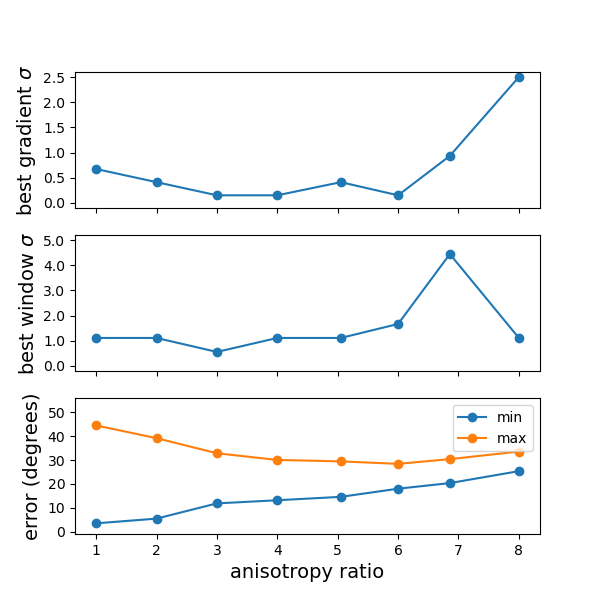

In [120]:
# plot the best sigma 1 and best sigma 2 versus the anisotropy ratio
fig, axs = plt.subplots(3, figsize=(6,6), sharex=True)
axs[0].plot(AI, derivative_sigmas[best_idx[:,0].astype(int)], marker='o')
axs[0].set_ylim(-0.1,2.6)
axs[0].set_yticks(np.arange(0.0,3.0,0.5))
axs[0].set_ylabel(r'best gradient $\sigma$')
axs[1].plot(AI, tensor_sigmas[best_idx[:,1].astype(int)], marker='o')
axs[1].set_ylim(-0.2,5.2)
yticklabels = [f'{y:.1f}'for y in np.arange(0.0,6.0,1.0)]
axs[1].set_yticks(np.arange(0.0,6.0,1.0))
axs[1].set_yticklabels(yticklabels)
axs[1].set_ylabel(r'best window $\sigma$')
axs[2].plot(AI, errors_min, marker='o')
axs[2].plot(AI, errors_max, marker='o')
axs[2].set_ylim(-1,56)
axs[2].set_yticks(np.arange(0,55,10))
axs[2].set_ylabel('error (degrees)')
axs[2].set_xlabel('anisotropy ratio')
axs[2].legend(['min', 'max'])
# fig.suptitle('2D Two Angles')

fig.savefig('../outputs/sta_validate_outputs/figures/2d_two_angles_lines'+DATE+'.png')

# 3D experiments

## Experiment 4: single orientation

In [31]:
# concatenate all the pandas dataframes corresponding to phantoms with a single angle
sta_out = 'sta_3d_3_angles_out'
# sta_out = 'sta_3d_out_7-25-24/'

# sta_out = '../outputs/sta_validate_outputs/sta_3d_out_v7/'
# sta_out = '../outputs/sta_validate_outputs/sta_3d_iso-blur_out_v7/'
# sta_out = '../outputs/sta_validate_outputs/sta_3d_BF_out/'

files = os.listdir(os.path.join(path,sta_out))
# files = [f for f in files if f.split('theta-')[1][4]=='_'] # only get the files with one line angle
errors_df = pickle.load(open(os.path.join(path,sta_out,files[0]), 'rb'))
for f in files[1:]:
    errors_df = pd.concat([errors_df, pickle.load(open(os.path.join(path,sta_out,f), 'rb'))], axis=0)
derivative_sigmas = errors_df['derivative_sigma'].unique()
tensor_sigmas = errors_df['tensor_sigma'].unique()
AI = np.sort(errors_df['AI'].unique())

print(len(files))
print(derivative_sigmas)
print(tensor_sigmas)
errors_df.iloc[0]

2400
[0.15       0.41111111 0.67222222 0.93333333 1.19444444 1.45555556
 1.71666667 1.97777778 2.23888889 2.5       ]
[0.         0.55555556 1.11111111 1.66666667 2.22222222 2.77777778
 3.33333333 3.88888889 4.44444444 5.        ]


derivative_sigma                                                 0.15
tensor_sigma                                                      0.0
AI                                                                2.0
period                                                           13.0
width                                                             1.0
angles              [[1.8673262079432749, 1.6155950286258867], [2....
error                                                       50.117664
Name: 0, dtype: object

In [32]:
out = '/home/brysongray/structure_tensor_validation/outputs'
# name = '3d_single_angle_phantom_sta_errors_' + DATE + '.csv'
name = '3d_three_angle_phantom_sta_errors_' + DATE + '.csv'
errors_df.to_csv(os.path.join(out, name))

## figure 7: heatmap of errors for sigma 1 vs sigma 2 at each anisotropy

In [33]:
# average errors_df over all angles and periods
if error_key == 'error':
    errors_df_grouped = errors_df.groupby(['derivative_sigma', 'tensor_sigma', 'AI'])[error_key].median().reset_index()
else:
    errors_df_grouped = errors_df.groupby(['derivative_sigma', 'tensor_sigma', 'AI'])['mean_err'].median().reset_index()
errors_df_grouped.iloc[79:85]

,derivative_sigma,tensor_sigma,AI,error
79,0.150000,5.0,8.000000,54.656597
80,0.411111,0.0,1.000000,28.296590
81,0.411111,0.0,2.000000,30.942220
82,0.411111,0.0,3.000000,32.557278
83,0.411111,0.0,4.000000,33.667684
84,0.411111,0.0,5.142857,33.969540


In [34]:
errors = errors_df_grouped[error_key].values.reshape((len(derivative_sigmas), len(tensor_sigmas), len(AI)))

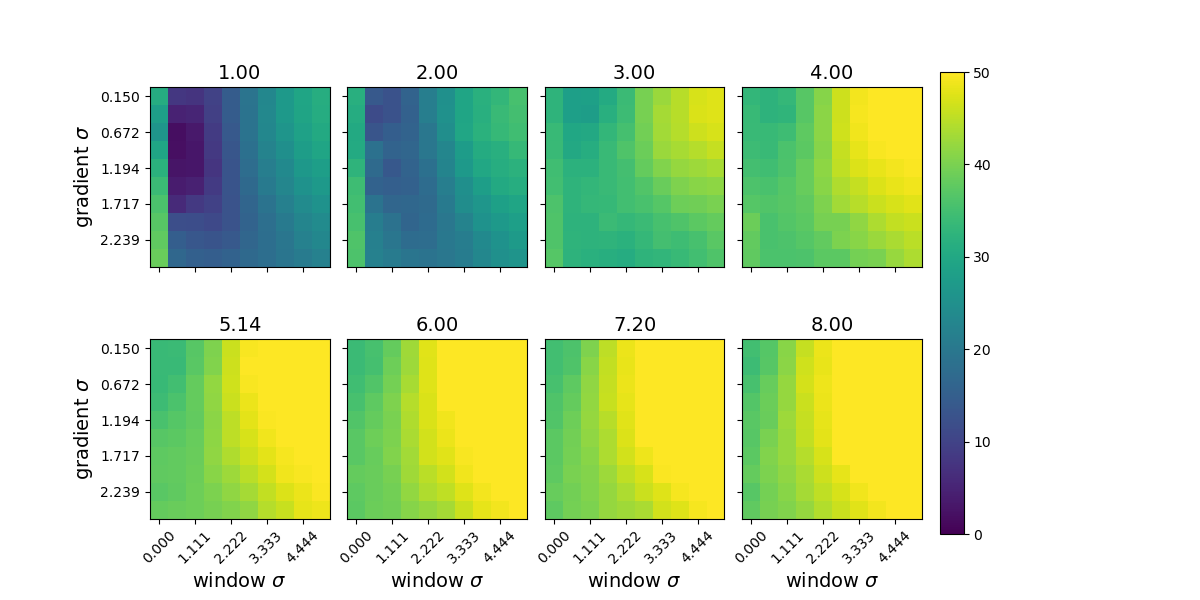

In [36]:
rows = 2
cols = 4
vm = 50
fig, axs = plt.subplots(rows,cols, figsize=(12,6), sharex=True, sharey=True)
for i in range(len(AI)):
    error = errors[...,i]
    axs[i//cols,i%cols].imshow(error, vmin=0, vmax=vm)
    axs[i//cols,i%cols].set_title(f'{AI[i]:.2f}')
    # set x tick labels
    # set the locations of the xticks and yticks
    xticklabels = [f'{t:.3f}' for t in tensor_sigmas]
    yticklabels = [f'{d:.3f}' for d in derivative_sigmas]
    axs[i//cols, i%cols].set_xticks(np.arange(len(tensor_sigmas))[::2])
    axs[i//cols, i%cols].set_yticks(np.arange(len(derivative_sigmas))[::2])
    axs[i//cols, i%cols].set_xticklabels(xticklabels[::2], rotation=45)
    axs[i//cols, i%cols].set_yticklabels(yticklabels[::2])
    if i%cols==0:
        axs[i//cols,i%cols].set_ylabel(r'gradient $\sigma$')
    if i > cols * (rows-1) - 1:
        axs[i//cols,i%cols].set_xlabel(r'window $\sigma$')
    plt.subplots_adjust(wspace=0.1, hspace=0.2)
# add colorbar to the right
cbar = fig.colorbar(axs[0,0].images[0], ax=axs, location='right', pad=0.02)

fig.savefig('../outputs/sta_validate_outputs/figures/heatmaps_3d_three_angle_'+DATE+'.png')

## figure 8: The smallest average single-angle error, optimized over sigmas, versus anisotropy ratio.

In [37]:
# min the error array over the first two axes
errors_min = np.min(errors, axis=(0,1))
errors_max = np.max(errors[:,1:], axis=(0,1))
# plot the min error for each anisotropy ratio
# plt.figure()
# # set figure title
# plt.plot(AI, errors_min, marker='o')
# plt.ylim(-1,56)
# plt.yticks(np.arange(0,60,5))
# plt.xlabel('anisotropy ratio')
# plt.ylabel('min error (degrees)')

In [38]:
print(errors_min)

[ 1.82245355 11.50512846 27.84951014 32.39897217 33.62428025 34.05649255
 34.83001007 34.27234814]


## figure 9: The best sigma 1 and sigma 2 vs anisotropy ratio.

In [39]:
# get the sigmas at argmin of the error over the anisotropy axis
best_idx = np.empty((len(AI), 2))
for i in range(len(AI)):
    best_idx[i] = np.array(np.unravel_index(np.argmin(errors[...,i]), errors.shape[:-1]))

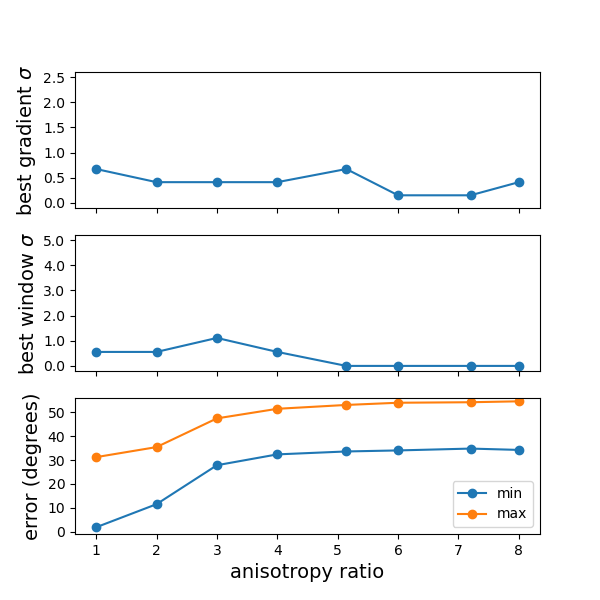

In [40]:
# plot the best sigma 1 and best sigma 2 versus the anisotropy ratio
fig, axs = plt.subplots(3, figsize=(6,6), sharex=True)
axs[0].plot(AI, derivative_sigmas[best_idx[:,0].astype(int)], marker='o')
axs[0].set_ylim(-0.1,2.6)
axs[0].set_yticks(np.arange(0.0,3.0,0.5))
axs[0].set_ylabel(r'best gradient $\sigma$')
axs[1].plot(AI, tensor_sigmas[best_idx[:,1].astype(int)], marker='o')
axs[1].set_ylim(-0.2,5.2)
yticklabels = [f'{y:.1f}'for y in np.arange(0.0,6.0,1.0)]
axs[1].set_yticks(np.arange(0.0,6.0,1.0))
axs[1].set_yticklabels(yticklabels)
axs[1].set_ylabel(r'best window $\sigma$')
axs[2].plot(AI, errors_min, marker='o')
axs[2].plot(AI, errors_max, marker='o')
axs[2].set_ylim(-1,56)
axs[2].set_yticks(np.arange(0,55,10))
axs[2].set_ylabel('error (degrees)')
axs[2].set_xlabel('anisotropy ratio')
axs[2].legend(['min', 'max'])

fig.savefig('../outputs/sta_validate_outputs/figures/3d_three_angle_lines'+DATE+'.png')

## Error vs angle

PearsonRResult(statistic=0.01004847767858782, pvalue=0.9209604782108385)


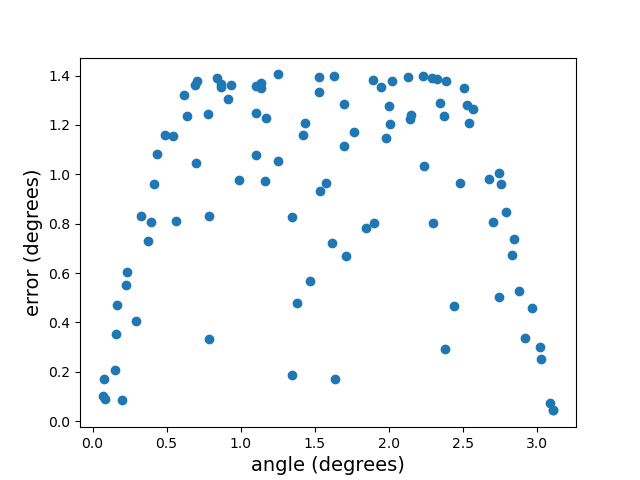

In [129]:
import scipy


df = errors_df.query(f'derivative_sigma=={derivative_sigmas[7]} and tensor_sigma=={tensor_sigmas[9]} and AI==1.0 and period==10.0')

errors = df[error_key]
angles = df['angles']
angles = np.array([np.array(a) for a in angles])
plt.figure()
plt.scatter(angles[:,1], errors)
plt.xlabel('angle (degrees)')
plt.ylabel('error (degrees)')
correlation = scipy.stats.pearsonr(angles[:,0], errors)
print(correlation)

## Experiment 5: 3D two angles

In [11]:
files = os.listdir(os.path.join(path,sta_out))
files = [f for f in files if f.split('theta-')[1][4]=='-'] # only get the files with two line angles
errors_df = pickle.load(open(os.path.join(path,sta_out,files[0]), 'rb'))
for f in files[1:]:
    errors_df = pd.concat([errors_df, pickle.load(open(os.path.join(path,sta_out,f), 'rb'))], axis=0)
derivative_sigmas = errors_df['derivative_sigma'].unique()
tensor_sigmas = errors_df['tensor_sigma'].unique()
AI = np.sort(errors_df['AI'].unique())

In [12]:
out = '/home/brysongray/structure_tensor_validation/outputs'
name = '3d_two_angle_phantom_sta_errors_' + DATE + '.csv'
errors_df.to_csv(os.path.join(out, name))

## figure 10: heatmap of errors for sigma 1 vs sigma 2 at each anisotropy

In [131]:
if error_key == 'error':
    errors_df_grouped = errors_df.groupby(['derivative_sigma', 'tensor_sigma', 'AI'])[error_key].median().reset_index()
else:
    errors_df_grouped = errors_df.groupby(['derivative_sigma', 'tensor_sigma', 'AI'])['mean_err'].median().reset_index()
errors = errors_df_grouped[error_key].values.reshape((len(derivative_sigmas), len(tensor_sigmas), len(AI)))

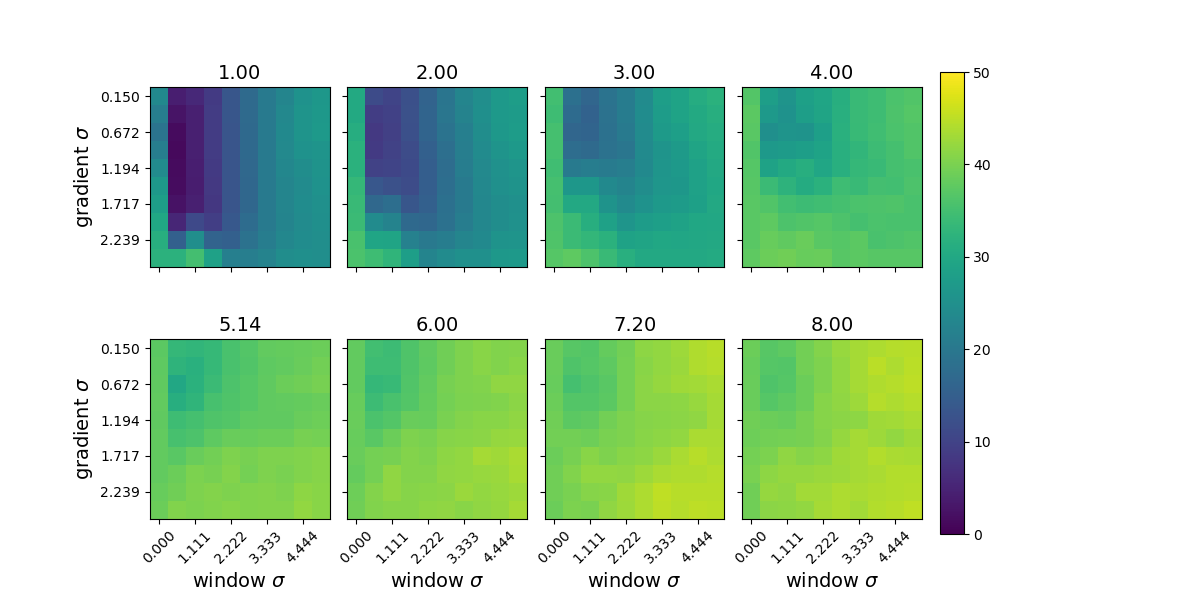

In [132]:
rows = 2
cols = 4
vm = 50
fig, axs = plt.subplots(rows,cols, figsize=(12,6), sharex=True, sharey=True)
for i in range(len(AI)):
    error = errors[...,i]
    axs[i//cols,i%cols].imshow(error, vmin=0, vmax=vm)
    axs[i//cols,i%cols].set_title(f'{AI[i]:.2f}')
    # set x tick labels
    # set the locations of the xticks and yticks
    xticklabels = [f'{t:.3f}' for t in tensor_sigmas]
    yticklabels = [f'{d:.3f}' for d in derivative_sigmas]
    axs[i//cols, i%cols].set_xticks(np.arange(len(tensor_sigmas))[::2])
    axs[i//cols, i%cols].set_yticks(np.arange(len(derivative_sigmas))[::2])
    axs[i//cols, i%cols].set_xticklabels(xticklabels[::2], rotation=45)
    axs[i//cols, i%cols].set_yticklabels(yticklabels[::2])
    if i%cols==0:
        axs[i//cols,i%cols].set_ylabel(r'gradient $\sigma$')
    if i > cols * (rows-1) - 1:
        axs[i//cols,i%cols].set_xlabel(r'window $\sigma$')
    plt.subplots_adjust(wspace=0.1, hspace=0.2)
# add colorbar to the right
cbar = fig.colorbar(axs[0,0].images[0], ax=axs, location='right', pad=0.02)

# fig.savefig('../outputs/sta_validate_outputs/figures/heatmaps_3d_two_angles_'+DATE+'.png')

In [133]:
print(derivative_sigmas)
print(tensor_sigmas)

[0.15       0.41111111 0.67222222 0.93333333 1.19444444 1.45555556
 1.71666667 1.97777778 2.23888889 2.5       ]
[0.         0.55555556 1.11111111 1.66666667 2.22222222 2.77777778
 3.33333333 3.88888889 4.44444444 5.        ]


## figure 11: The smallest average single-angle error, optimized over sigmas, versus anisotropy ratio.

In [134]:
# min the error array over the first two axes
errors_min = np.min(errors, axis=(0,1))
errors_max = np.max(errors[:,1:], axis=(0,1))
# plot the min error for each anisotropy ratio
# plt.figure()
# # set figure title
# plt.plot(AI, errors_min, marker='o')
# plt.ylim(-1,56)
# plt.yticks(np.arange(0,60,5))
# plt.xlabel('anisotropy ratio')
# plt.ylabel('min error (degrees)')

## figure 12: The best sigma 1 and sigma 2 vs anisotropy ratio.

In [135]:
# get the sigmas at argmin of the error over the anisotropy axis
best_idx = np.empty((len(AI), 2))
for i in range(len(AI)):
    best_idx[i] = np.array(np.unravel_index(np.argmin(errors[...,i]), errors.shape[:-1]))

In [136]:
print(errors_min)

[ 1.33253554  8.22320288 15.72976729 24.86708864 30.0077741  33.29192949
 35.16258769 36.17495926]


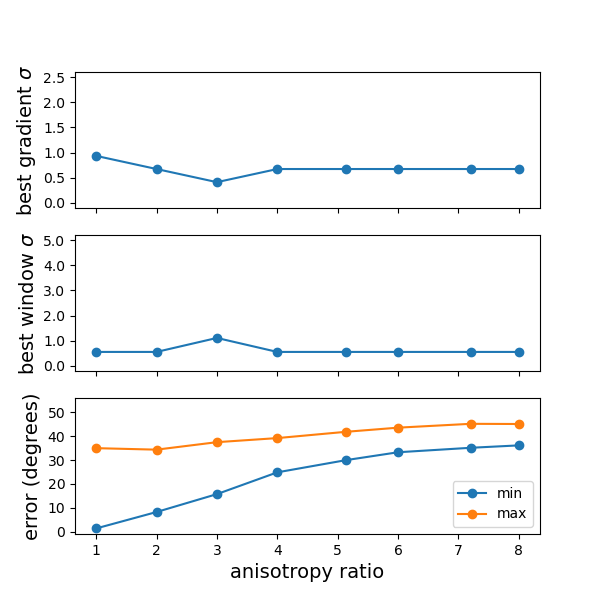

In [137]:
# plot the best sigma 1 and best sigma 2 versus the anisotropy ratio
fig, axs = plt.subplots(3, figsize=(6,6), sharex=True)
axs[0].plot(AI, derivative_sigmas[best_idx[:,0].astype(int)], marker='o')
axs[0].set_ylim(-0.1,2.6)
axs[0].set_yticks(np.arange(0.0,3.0,0.5))
axs[0].set_ylabel(r'best gradient $\sigma$')
axs[1].plot(AI, tensor_sigmas[best_idx[:,1].astype(int)], marker='o')
axs[1].set_ylim(-0.2,5.2)
yticklabels = [f'{y:.1f}'for y in np.arange(0.0,6.0,1.0)]
axs[1].set_yticks(np.arange(0.0,6.0,1.0))
axs[1].set_yticklabels(yticklabels)
axs[1].set_ylabel(r'best window $\sigma$')
axs[2].plot(AI, errors_min, marker='o')
axs[2].plot(AI, errors_max, marker='o')
axs[2].set_ylim(-1,56)
axs[2].set_yticks(np.arange(0,55,10))
axs[2].set_ylabel('error (degrees)')
axs[2].set_xlabel('anisotropy ratio')
axs[2].legend(['min', 'max'])
# fig.savefig('../outputs/sta_validate_outputs/figures/3d_two_angles_lines'+DATE+'.png')

## How does delta angle affect error?

In [47]:
df = errors_df.query(f'derivative_sigma=={derivative_sigmas[5]} and tensor_sigma=={tensor_sigmas[1]} and AI==1.0')
# Convert the 'angles' column to tuples to make it hashable
df['angles'] = df['angles'].apply(lambda x: tuple(map(tuple, x)) if isinstance(x, (np.ndarray, list)) else x)

# Perform the groupby operation
errors_ = df.groupby(['derivative_sigma', 'tensor_sigma', 'AI', 'angles'])[error_key].median().reset_index()

/tmp/ipykernel_1091499/2879172552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['angles'] = df['angles'].apply(lambda x: tuple(map(tuple, x)) if isinstance(x, (np.ndarray, list)) else x)


In [48]:
errors_

,derivative_sigma,tensor_sigma,AI,angles,error
0,1.455556,0.555556,1.0,"((0.28554140135337436, 2.443495833395774), (1....",2.336998
1,1.455556,0.555556,1.0,"((0.3090900404280907, 0.19996119763697268), (0...",3.952200
2,1.455556,0.555556,1.0,"((0.3090900404280907, 0.19996119763697268), (1...",3.422074
3,1.455556,0.555556,1.0,"((0.3090900404280907, 0.19996119763697268), (1...",16.920843
4,1.455556,0.555556,1.0,"((0.3090900404280907, 0.19996119763697268), (2...",2.886055
...,...,...,...,...,...
95,1.455556,0.555556,1.0,"((2.950730916896096, 0.784266044646252), (1.04...",3.288011
96,1.455556,0.555556,1.0,"((2.950730916896096, 0.784266044646252), (1.20...",1.934838
97,1.455556,0.555556,1.0,"((2.950730916896096, 0.784266044646252), (1.69...",2.791254
98,1.455556,0.555556,1.0,"((2.950730916896096, 0.784266044646252), (1.74...",1.778197


/tmp/ipykernel_1091499/354279242.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['angles'] = df['angles'].apply(lambda x: tuple(map(tuple, x)) if isinstance(x, (np.ndarray, list)) else x)


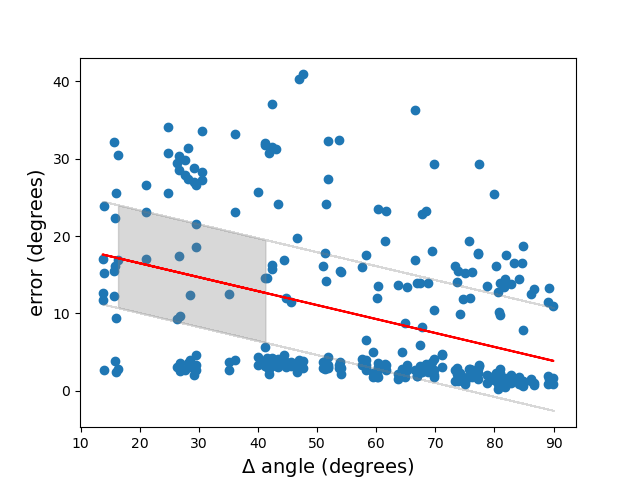

In [58]:
# df = errors_df.query(f'derivative_sigma=={derivative_sigmas[5]} and tensor_sigma=={tensor_sigmas[1]} and AI==1.0 and period==10.0')

df = errors_df.query(f'derivative_sigma=={derivative_sigmas[5]} and tensor_sigma=={tensor_sigmas[1]} and AI==1.0')
# Convert the 'angles' column to tuples to make it hashable
df['angles'] = df['angles'].apply(lambda x: tuple(map(tuple, x)) if isinstance(x, (np.ndarray, list)) else x)

# Perform the groupby operation
df_grouped = df.groupby(['derivative_sigma', 'tensor_sigma', 'AI', 'angles'])[error_key].median().reset_index()

errors = df[error_key]
angles = df['angles']
delta = np.empty(len(angles))
mean = np.empty((len(angles), 2))
for i,a in enumerate(angles):
    u = np.array([np.sin(a[0][0])*np.sin(a[0][1]), np.sin(a[0][0])*np.cos(a[0][1]), np.cos(a[0][0])])
    v = np.array([np.sin(a[1][0])*np.sin(a[1][1]), np.sin(a[1][0])*np.cos(a[1][1]), np.cos(a[1][0])])
    dp = np.dot(u,v)
    delta[i] = np.arccos(np.abs(dp)) * 180/np.pi
    sign = np.sign(dp)
    m = np.mean((sign*u,v), axis=0)
    m = m / np.linalg.norm(m)
    mean[i] = np.array([np.arccos(m[2]), np.arctan2(m[0], m[1])])

# scatter plot of errors by delta
plt.figure()
plt.scatter(delta, errors)
plt.xlabel(r'$\Delta$ angle (degrees)')
plt.ylabel('error (degrees)')

# Fit a linear trendline
slope, intercept = np.polyfit(delta, errors, 1)
trendline = slope * delta + intercept
plt.plot(delta, trendline, color='red')

# Calculate residuals
residuals = errors - trendline

# Compute 25th and 75th percentiles of residuals
lower_bound = trendline + np.percentile(residuals, 25)
upper_bound = trendline + np.percentile(residuals, 75)

# Plot confidence bounds
plt.fill_between(delta, lower_bound, upper_bound, color='gray', alpha=0.3)


# # histogram of errors
# plt.figure()
# plt.hist(errors, bins=20)
# plt.xlabel('error (degrees)')
# plt.ylabel('count')



In [98]:
df.iloc[0]['angles']

array([[1.09650466, 0.15863289],
       [1.84396009, 1.34946562]])

In [54]:
print(df.iloc[np.argmax(df[error_key])]['angles'])
print(df.iloc[np.argmax(df[error_key])])
print(derivative_sigmas[4])
print(tensor_sigmas[2])



[[1.81171368 0.07453413]
 [1.09650466 0.15863289]]
derivative_sigma                                             1.455556
tensor_sigma                                                 0.555556
AI                                                                1.0
period                                                           10.0
width                                                             1.0
angles              [[1.8117136834059988, 0.07453412612797515], [1...
error                                                       45.139642
Name: 51, dtype: object
1.1944444444444444
1.1111111111111112


# blur vs no blur Boxplot

In [55]:
def tuplizer(x):
    return tuple(x.flatten()) if isinstance(x, (np.ndarray, list)) else x

# load 2D unblurred data
sta_out = '../outputs/sta_validate_outputs/sta_2d-96_out_v7/'
files = os.listdir(sta_out)
errors_df = pickle.load(open(sta_out+files[0], 'rb'))
for f in files[1:]:
    errors_df = pd.concat([errors_df, pickle.load(open(sta_out+f, 'rb'))], axis=0)

errors_2d_min = errors_df.applymap(tuplizer)
errors_2d_min = errors_2d_min.groupby(['AI', 'period', 'angles'])[error_key].min().reset_index()
errors_2d_min = list(errors_2d_min['median_err'])

# load 2d blurred data
sta_out = '../outputs/sta_validate_outputs/sta_2d_iso-blur_out_v7/'
files = os.listdir(sta_out)
errors_df = pickle.load(open(sta_out+files[0], 'rb'))
for f in files[1:]:
    errors_df = pd.concat([errors_df, pickle.load(open(sta_out+f, 'rb'))], axis=0)

errors_2d_min_blur = errors_df.applymap(tuplizer)
errors_2d_min_blur = errors_2d_min_blur.groupby(['AI', 'period', 'angles'])[error_key].min().reset_index()
errors_2d_min_blur = list(errors_2d_min_blur['median_err'])

# load 3D unblurred data
sta_out = '../outputs/sta_validate_outputs/sta_3d_out_v7/'
files = os.listdir(sta_out)
errors_df = pickle.load(open(sta_out+files[0], 'rb'))
for f in files[1:]:
    errors_df = pd.concat([errors_df, pickle.load(open(sta_out+f, 'rb'))], axis=0)

errors_3d_min = errors_df.applymap(tuplizer)
errors_3d_min = errors_3d_min.groupby(['AI', 'period', 'angles'])[error_key].min().reset_index()
errors_3d_min = list(errors_3d_min['median_err'])

# load 3D blurred data
sta_out = '../outputs/sta_validate_outputs/sta_3d_iso-blur_out_v7/'
files = os.listdir(sta_out)
errors_df = pickle.load(open(sta_out+files[0], 'rb'))
for f in files[1:]:
    errors_df = pd.concat([errors_df, pickle.load(open(sta_out+f, 'rb'))], axis=0)

errors_3d_min_blur = errors_df.applymap(tuplizer)
errors_3d_min_blur = errors_3d_min_blur.groupby(['AI', 'period', 'angles'])[error_key].min().reset_index()
errors_3d_min_blur = list(errors_3d_min_blur['median_err'])



FileNotFoundError: [Errno 2] No such file or directory: '../outputs/sta_validate_outputs/sta_2d-96_out_v7/'

NameError: name 'errors_2d_min_blur' is not defined

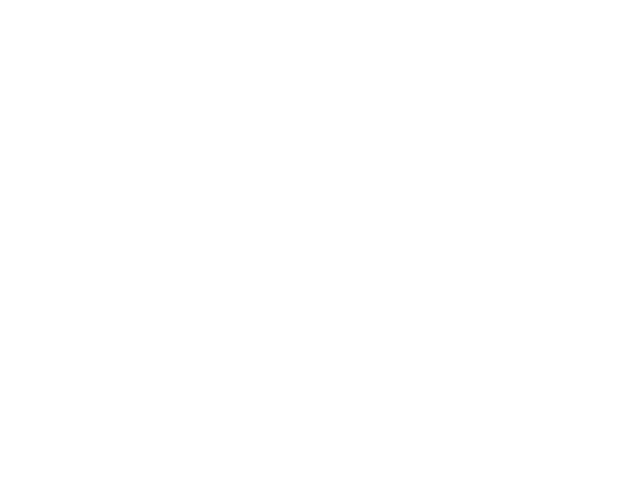

In [82]:
# box and whisker plot without outliers
plt.figure()
plt.boxplot([errors_2d_min, errors_2d_min_blur, errors_3d_min, errors_3d_min_blur], showfliers=False)
plt.xticks([1,2,3,4], ['2D', '2D with Blur', '3D', '3D with Blur'])
plt.ylabel('error (degrees)')


# Pipeline Figures

# first we generate a phantom with specified line orienations, period, and anisotropy  

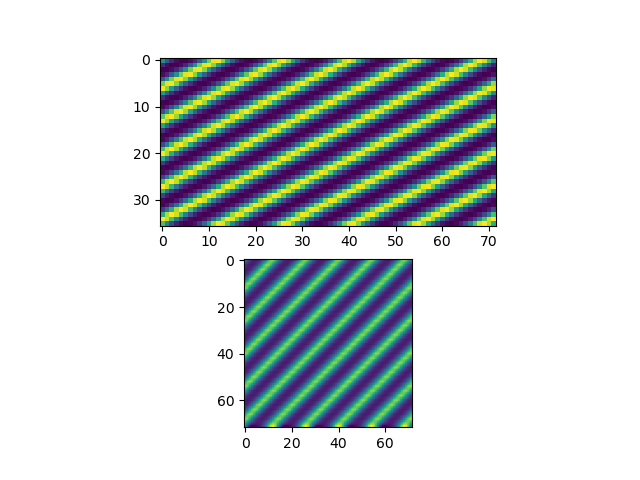

In [56]:
# in 2D
n = (36, 72)
d = (2.0, 1.0)
x = [np.arange(ni)*di for ni, di in zip(n, d)]
angles = np.array([3*np.pi/4])
img = sta_validate.make_phantom(x, angles, interp=False)
img_upsampled = sta_validate.make_phantom(x, angles)

fig, axs = plt.subplots(2)
axs[0].imshow(img)
axs[1].imshow(img_upsampled)

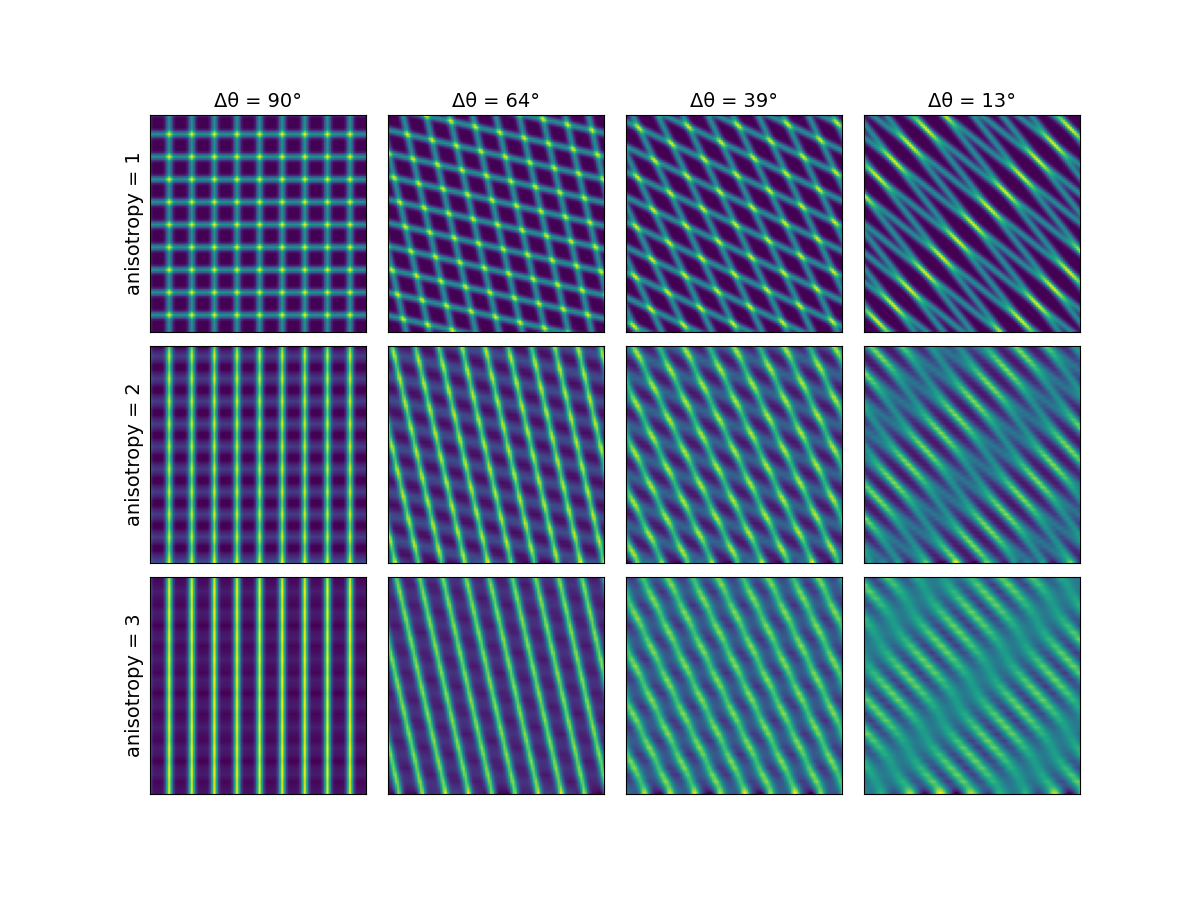

In [57]:
# in 2D
shapes = [(96,96), (48,96), (32,96)]
AI = [d[1]/d[0] for d in shapes]
periods = [7,10,13]
thetas = np.linspace(0,np.pi/2,8)
theta_pairs = np.array([[thetas[0], thetas[7]],
                        [thetas[1], thetas[6]],
                        [thetas[2], thetas[5]],
                        [thetas[3], thetas[4]]])

fig, axs = plt.subplots(3,4, figsize=(12,9))
plt.subplots_adjust(hspace=0.0, wspace=0.1)
for i,n in enumerate(shapes):
    d = (n[1]/n[0], 1.0)
    x = [np.arange(ni)*di for ni, di in zip(n, d)]
    for j,a in enumerate(theta_pairs):
            image = sta_validate.make_phantom(x,a, periods[1], inverse=False)
            axs[i,j].imshow(image)
            axs[i,j].set_xticks([])
            axs[i,j].set_yticks([])
            if i==0:
                  axs[i,j].set_title(f"\u0394\u03B8 = {np.abs(a[0]-a[1])*180/np.pi:.0f}\u00B0")
            if j==0:
                  axs[i,j].set_ylabel(f"anisotropy = {i+1}")



In [53]:
errors_df['angles'].iloc[0].shape


(2, 2)

In [54]:
plt.close('all')

In [55]:
print(derivative_sigmas[2])
print(tensor_sigmas[1])

0.6722222222222223
0.5555555555555556


[[0.         0.        ]
 [1.04719755 0.        ]]


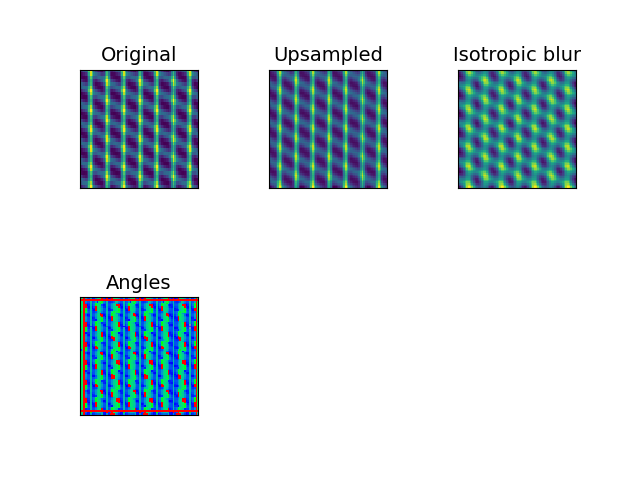

In [56]:
# in 3D
# shapes = [(72,72,72), (36,72,72), (24,72,72), (18,72,72), (14,72,72), (12,72,72), (10,72,72), (9,72,72)]
# shapes = [(72,72,72), (24,72,72), (14,72,72), (10,72,72)]
shapes = [(36,72,72)]


AI = [d[1]/d[0] for d in shapes]
period=10.0
sigma0 = derivative_sigmas[2]
sigma1 = tensor_sigmas[1]
true_thetas = np.array([np.pi/4, 3*np.pi/4])
# true_thetas = errors_df['angles'].iloc[0]
# true_thetas = np.array([[np.pi/3, 0.0]])
true_thetas = np.array([[0.0, 0.0],
                        [np.pi/3, 0.0]])
# true_thetas = np.array([[1.09650466, 0.15863289],
#                         [1.84396009, 1.34946562]])
print(true_thetas)
fig, ax = plt.subplots(2,3)
angles_dist = []
for i in range(1): #ax.shape[1]):
    n = shapes[i]
    d = (n[1]/n[0], 1.0, 1.0)
    x = [np.arange(ni)*di for ni, di in zip(n, d)]
    crop = round(max(sigma0,sigma1)*8.0/3) # two-thirds the radius of the largest kernel
    crop_end = round(AI[i]) - 1
    img = sta_validate.make_phantom(x, true_thetas, period=period, interp=False,)
    img_up = sta_validate.make_phantom(x, true_thetas, period=period)
    img_blur = sta_validate.make_phantom(x, true_thetas, period=period, blur_correction=True)
    # img_up = np.random.randn(72,72,72) * 1e-6
    S = histology.structure_tensor(img_up, derivative_sigma=sigma0, tensor_sigma=sigma1, masked=False)
    angles = histology.angles(S, cartesian=True)
    angles_dist.append(angles[crop:-(crop+crop_end), crop:-crop, crop:-crop].reshape(-1,3)) # save for k-means
    # angles_ = (angles - np.min(angles)) / (np.max(angles)-np.min(angles))
    angles_ = np.abs(angles)
    crop_color = [1.0,0.0,0.0]
    angles_[crop] = crop_color
    angles_[-crop-crop_end] = crop_color
    angles_[:,crop] = crop_color
    angles_[:,-crop] = crop_color
    angles_[:,:,crop] = crop_color
    angles_[:,:,-crop] = crop_color
    extent = (x[1][0]-d[1]/2, x[1][-1]+d[1]/2, x[0][-1]+d[0]/2, x[0][0]-d[0]/2)

    # ax[0][i].imshow(img[:,:,36], extent=extent, interpolation='none')
    # ax[0][i].set_title(f'AI = {d[0]:.2f}')
    # ax[1][i].imshow(img_up[:,:,36], extent=extent, vmin=1e-6, interpolation='none')
    # ax[2][i].imshow(img_blur[:,:,36], extent=extent, interpolation='none')
    # ax[3][i].imshow(angles_[:,:,36], extent=extent, interpolation='none')

    # ax[0].imshow(img[:,:,36], extent=extent, interpolation='none')#, vmin=1e-3)
    # ax[0].set_title(f'Original')
    # ax[1].imshow(img_up[:,:,36], extent=extent, interpolation='none')#, vmin=2e-2)
    # ax[1].set_title('Upsampled')
    # ax[2].imshow(img_blur[:,:,36], extent=extent, interpolation='none')#, vmin=2e-2)
    # ax[2].set_title('Isotropic blur')
    # ax[3].imshow(angles_[:,:,36], extent=extent, interpolation='none')
    # ax[3].set_title('Angles')

    ax[0][0].imshow(img[:,:,36], extent=extent, interpolation='none')#, vmin=1e-3)
    ax[0][0].set_title('Original')
    ax[0][0].set_xticks([])
    ax[0][0].set_yticks([])
    ax[0][1].imshow(img_up[:,:,36], extent=extent, interpolation='none')#, vmin=2e-2)
    ax[0][1].set_title('Upsampled')
    ax[0][1].set_xticks([])
    ax[0][1].set_yticks([])
    ax[0][2].imshow(img_blur[:,:,36], extent=extent, interpolation='none')#, vmin=2e-2)
    ax[0][2].set_title('Isotropic blur')
    ax[0][2].set_xticks([])
    ax[0][2].set_yticks([])
    ax[1][0].imshow(angles_[:,:,36], extent=extent, interpolation='none')
    ax[1][0].set_title('Angles')
    ax[1][0].set_xticks([])
    ax[1][0].set_yticks([])
    ax[1][1].set_axis_off()
    ax[1][2].set_axis_off()

    plt.subplots_adjust(hspace=0.6, wspace=0.6)#, hspace=0.5)

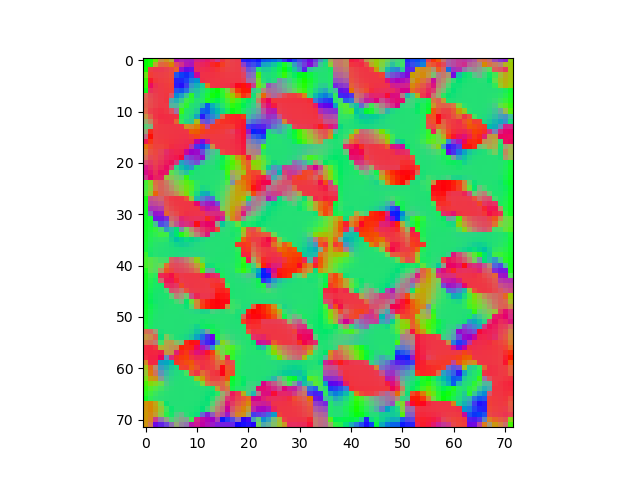

In [13]:
fig = plt.figure()
plt.imshow(np.abs(angles)[:,:,36], extent=extent, interpolation='none')

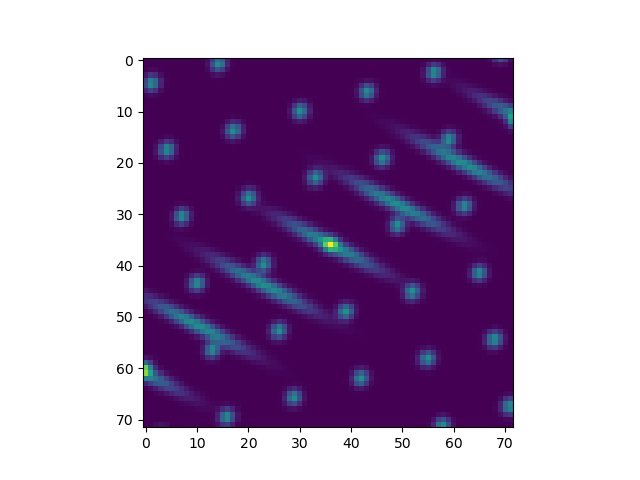

In [14]:
fig = plt.figure()
plt.imshow(img[:,:,36], extent=extent, interpolation='none')

In [15]:
true_thetas_cart = np.array([np.sin(true_thetas[:,0])*np.sin(true_thetas[:,1]),
                                    np.sin(true_thetas[:,0])*np.cos(true_thetas[:,1]),
                                    np.cos(true_thetas[:,0])
                                    ]).T

skm = apsym_kmeans.APSymKMeans(n_clusters=2)

mu_list = []
diff = []
for i in range(len(angles_dist)):
    skm.fit(angles_dist[i])
    mu_list.append(skm.cluster_centers_) # shape (n_clusters, n_features)
    diff_ = np.empty((len(mu_list[i]),len(true_thetas_cart))) # shape (2,2) for two permutations of the difference between two means and two true_thetas
    for m in range(len(mu_list[i])):
        for n in range(len(true_thetas_cart)):
            diff_[m,n] = np.arccos(np.abs(mu_list[i][m].dot(true_thetas_cart[n])))
    argmax = np.unravel_index(np.argmin(diff_), (2,2))
    corrolary = tuple([1 - x for x in argmax]) # the corresponding cos_dif of the other mu to the other grid_theta
    diff.append(np.mean([diff_[argmax], diff_[corrolary]]) * 180/np.pi)
error = np.mean(diff)
print(error)

IndexError: too many indices for array: array is 0-dimensional, but 2 were indexed

In [16]:
skm = apsym_kmeans.APSymKMeans(n_clusters=2)
angles_ = angles[crop:-crop-crop_end, crop:-crop, crop:-crop].reshape(-1,3)
skm.fit(angles_)
mu = skm.cluster_centers_
mu

array([[-0.94233596, -0.21359729,  0.25764148],
       [ 0.1482013 ,  0.87875343,  0.45368357]])

In [17]:
# helper functions for visualization
WINDOW_SIZE = (900, 900)
SAVEIM_FOLDER = 'images'
if not os.path.exists(SAVEIM_FOLDER):
    os.mkdir(SAVEIM_FOLDER)

def screenshot_animated_sf(sf, sphere, rot=True, norm=True, scale=True, title='Modeling', theta_step=30, mu=None, true_thetas=None):
    '''
    Render a spherical function to file. Returns path to image.
    '''
    
    scene = window.Scene()
    scene.background(window.colors.white)
    
    sf_actor = actor.odf_slicer(sf[None, None, None, :],
                               sphere=sphere, colormap='jet',
                               norm=norm, )#, radial_scale=scale)
    scene.add(sf_actor)

    is_mu = mu is not None
    is_true_thetas = true_thetas is not None

    if is_mu:
        mu_lines = np.array([[mu[0],-mu[0]],
                        [mu[1],-mu[1]]]) / 1.5
        mu_colors = np.array([[0,1,0],
                        [0,1,0]])
        lines = mu_lines
        colors = mu_colors

    if is_true_thetas:
        true_thetas = np.array([np.sin(true_thetas[:,1])*np.sin(true_thetas[:,0]),
                        np.cos(true_thetas[:,1])*np.sin(true_thetas[:,0]),
                        np.cos(true_thetas[:,0])]).T
        
        true_lines = np.array([[true_thetas[0],-true_thetas[0]],
                        [true_thetas[1],-true_thetas[1]]]) / 1.5
        true_colors = np.array([[0.6,0.2,0.95],
                        [0.6,0.2,0.95]])
        lines = true_lines
        colors = true_colors

    if is_mu and is_true_thetas:
            lines = np.concatenate((mu_lines, true_lines), axis=0)
            colors = np.concatenate((mu_colors, true_colors), axis=0)
    
    if is_mu or is_true_thetas:
        lines_actor = actor.line(lines, colors=colors, linewidth=3)
        scene.add(lines_actor)
        if rot:
            lines_actor.RotateX(90)
            lines_actor.RotateZ(270)
            # lines_actor.RotateY(90)

    if rot:
        sf_actor.RotateX(90)
        sf_actor.RotateZ(270)
        # sf_actor.RotateY(90)
    
    images = []
    n_frames = 360//theta_step
    for i in np.arange(n_frames):
        sf_actor.RotateZ(theta_step)
        if mu is not None:
            lines_actor.RotateZ(theta_step)

        scene.reset_clipping_range()
        images.append(PILImage.fromarray(window.snapshot(scene, size=WINDOW_SIZE)))
        
    frame_duration = 20000 // theta_step
    filename = os.path.join(SAVEIM_FOLDER, '{0}.gif'.format(title))
    images[0].save(filename, save_all=True, append_images=images[1:],
                  duration=frame_duration, optimize=False, loop=0)
    scene.clear()

    return filename
    
def screenshot_gradients(sph_gtab, title='Modeling'):
    scene = window.Scene()
    scene.background(window.colors.white)

    scene.add(actor.point(sph_gtab.vertices, window.colors.green, point_radius=0.05))

    outfile = os.path.join(SAVEIM_FOLDER, '{0}.png'.format(title))
    window.snapshot(scene, size=WINDOW_SIZE, fname=outfile)

    scene.clear()
    return outfile
        

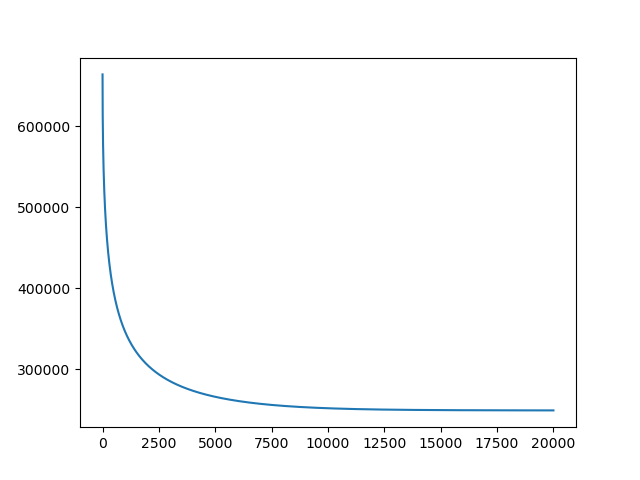

In [18]:
n_pts = 256
theta = np.pi - np.random.rand(n_pts)
phi = 2 * np.pi - np.random.rand(n_pts)
hsph_initial = HemiSphere(theta=theta, phi=phi)
hsph_updated, potential = disperse_charges(hsph_initial,20000, const=0.4)

vertices = hsph_updated.vertices
# values = np.ones(vertices.shape[0])
# bvecs = np.vstack((vertices))
# bvals = np.hstack((bvalue * values))
# # add some b=0 bvals/bvecs
# bvecs = np.insert(bvecs, (0,bvecs.shape[0]), np.array([0,0,0]), axis = 0)
# bvals = np.insert(bvals, (0, bvals.shape[0]), 0)

# gtab = gradient_table(bvals, bvecs)
sph_gtab = Sphere(xyz=np.vstack((vertices,-vertices)))

plt.figure()
plt.plot(potential)

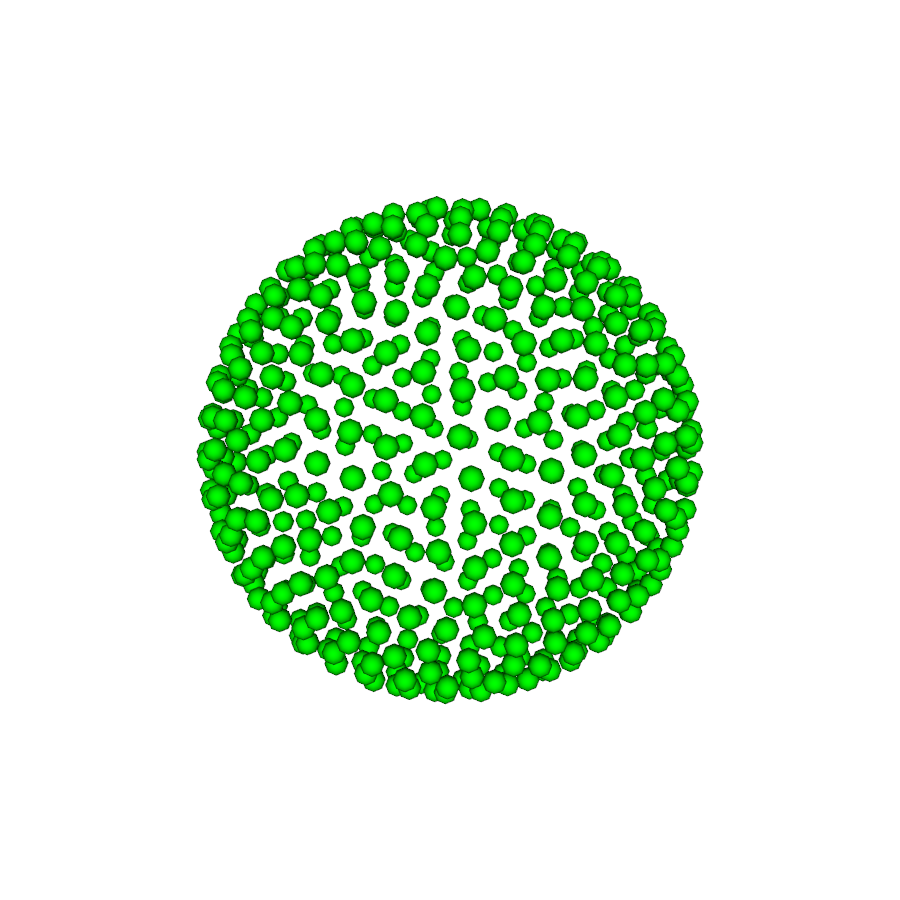

In [19]:
image = screenshot_gradients(sph_gtab, title='Example directions')
Image(filename=image)

In [20]:
# count the number of angles closest to each vertex
hist_sph_list = []
for i in range(len(angles_dist)):
    ids = np.argmax(np.abs(angles_dist[i] @ vertices.T), axis=1)
    unique, counts = np.unique(ids, return_counts=True)
    hist = np.zeros(vertices.shape[0])
    hist[unique] = counts
    hist_sph = np.zeros(vertices.shape[0]*2)
    hist_sph[:vertices.shape[0]] = hist
    hist_sph[vertices.shape[0]:] = hist
    hist_sph_list.append(hist_sph)

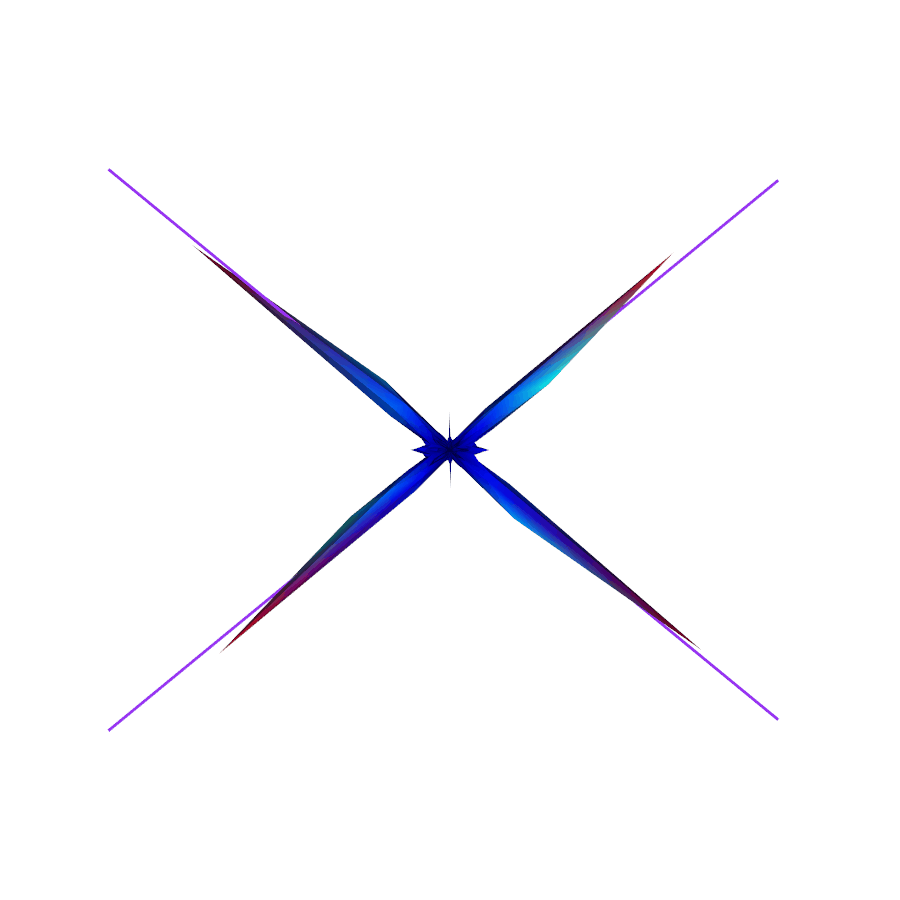

In [111]:
image = screenshot_animated_sf(hist_sph_list[0], sph_gtab, title='Histogram of STA angles', theta_step=360, rot=True, mu=None, true_thetas=true_thetas)
Image(filename=image)

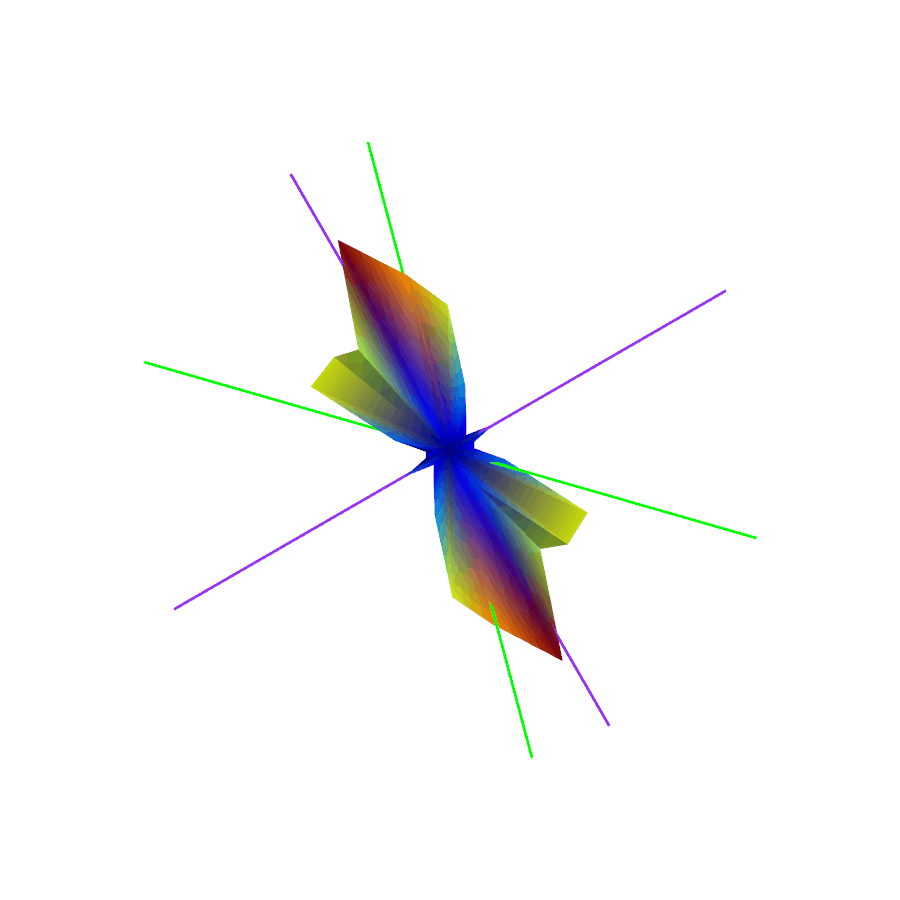

In [47]:
image = screenshot_animated_sf(hist_sph_list[1], sph_gtab, title='Histogram of STA angles', theta_step=360, rot=True, mu=mu_list[1], true_thetas=true_thetas)
Image(filename=image)

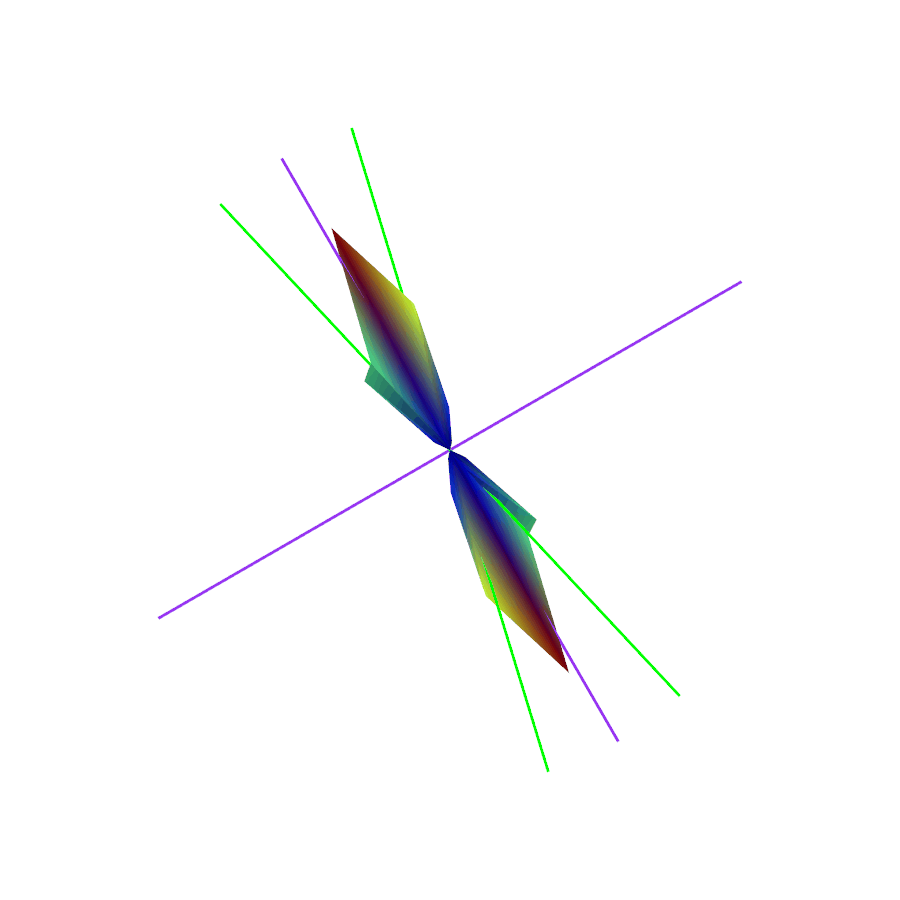

In [48]:
image = screenshot_animated_sf(hist_sph_list[2], sph_gtab, title='Histogram of STA angles', theta_step=360, rot=True, mu=mu_list[2], true_thetas=true_thetas)
Image(filename=image)

In [21]:
image = screenshot_animated_sf(hist_sph_list[3], sph_gtab, title='Histogram of STA angles', theta_step=360, rot=True, mu=mu_list[3], true_thetas=true_thetas)
Image(filename=image)

IndexError: list index out of range

In [ ]:
# visualize with volume plot
Z,Y,X = np.mgrid[0:72:1,0:72:1,0:72:1]

fig = go.Figure(data=go.Volume(
    x=X.flatten(),
    y=Y.flatten(),
    z=Z.flatten(),
    value=img.flatten(),
    isomin=0.04,
    isomax=0.23,
    opacity=0.5, # needs to be small to see through all surfaces
    surface_count=8, # needs to be a large number for good volume rendering
    ))
fig.update_layout(
    autosize=True,
    width=800,
    height=800,)
fig.show()
# py.iplot(fig, filename='volume_rendering')


## Next compute angles from structure tensors

In [55]:
n = (72, 72)
d = (1.0, 1.0)
x = [np.arange(ni)*di for ni, di in zip(n, d)]
angles = np.array([0])
img = sta_validate.make_phantom(x, angles, interp=True)
# img_upsampled = sta_validate.make_phantom(x, angles)

In [56]:
S = histology.structure_tensor(img, derivative_sigma=0.75, tensor_sigma=5.0, masked=False)
angles = histology.angles(S)
# plt.figure()
# plt.imshow(angles[:,36,:,0])#, cmap='hsv')
# plt.colorbar()

In [50]:
angles.shape

(72, 72)

In [57]:
print(np.min(angles), np.max(angles))

-0.024410538769541818 0.02116536231651908


In [ ]:
angles_ = angles.reshape((-1,angles.shape[-1]))

true_thetas_ = np.array([np.sin(true_thetas[0])*np.sin(true_thetas[1]),
                                np.sin(true_thetas[0])*np.cos(true_thetas[1]),
                                np.cos(true_thetas[0])
                                ])
skm = apsym_kmeans.APSymKMeans(n_clusters=1)
skm.fit(angles_)
mu_ = skm.cluster_centers_
# convert mu_ from cartesian to spherical coordinates
mu = np.array([np.arccos(mu_[0][2]), np.arctan2(mu_[0][0], mu_[0][1])])
diff = np.arccos(np.abs(mu_.dot(true_thetas_))) * 180/np.pi

print(mu)
print(true_thetas)

In [ ]:
print(diff)